## classic model

In [3]:
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from tensorflow.keras.callbacks import ModelCheckpoint

In [ ]:
df_classic = pd.read_csv(r"/content/cleaned_phishing_dataset_with_features.csv")

In [ ]:
df_classic

,url,label,url_length,domain_length,path_length,query_length,num_dots,num_hyphens,num_underscores,num_slashes,...,contains_secure,contains_bank,contains_paypal,contains_confirm,contains_password,contains_webscr,contains_ebay,contains_wp,contains_admin,entropy
0,https://www.google.com,1,22.0,14.0,0.0,0.0,2.0,0.0,0.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.663533
1,https://www.youtube.com,1,23.0,15.0,0.0,0.0,2.0,0.0,0.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.762267
2,https://www.facebook.com,1,24.0,16.0,0.0,0.0,2.0,0.0,0.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.855389
3,https://www.baidu.com,1,21.0,13.0,0.0,0.0,2.0,0.0,0.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.880180
4,https://www.wikipedia.org,1,25.0,17.0,0.0,0.0,2.0,0.0,0.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.813661
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
781895,https://www.skincareliving.com,1,30.0,22.0,0.0,0.0,2.0,0.0,0.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.189898
781896,https://www.winchester.gov.uk,1,29.0,21.0,0.0,0.0,3.0,0.0,0.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.978334
781897,https://www.nononsensedesign.be,1,31.0,23.0,0.0,0.0,2.0,0.0,0.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.652115
781898,https://patient-cell-40f5.updatedlogmylogin.wo...,0,56.0,47.0,1.0,0.0,3.0,2.0,0.0,3.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.575324


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,precision_recall_curve,precision_score,recall_score,confusion_matrix,roc_curve,roc_auc_score,f1_score,classification_report

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, AdaBoostClassifier, GradientBoostingClassifier

In [ ]:
x =df_classic.drop(['label','url'],axis=1)
y =df_classic['label']

In [ ]:
!pip install xgboost lightgbm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.7/98.7 MB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 89.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 303.4/303.4 MB 1.2 MB/s eta 0:00:00


In [ ]:
weights = (y.value_counts()/y.shape[0]).to_dict()

## feature selection and extraction

### Feature Selection using Mutual Information
We will calculate the mutual information scores to see which features provide the most information about the target label.

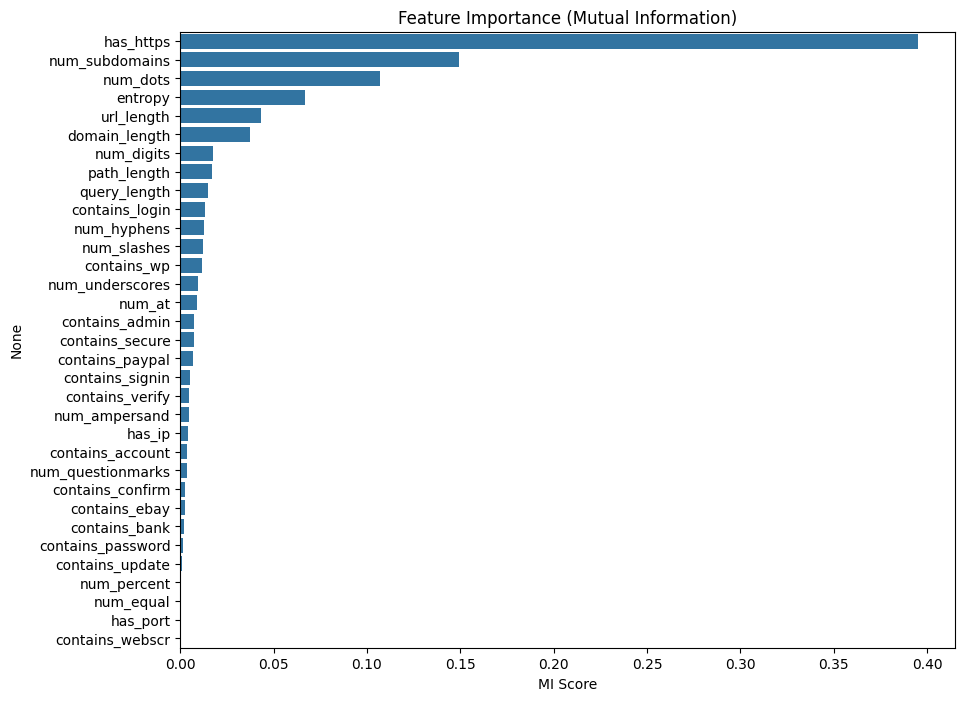

Selected 13 features based on MI score.


In [ ]:
from sklearn.feature_selection import mutual_info_classif
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate Mutual Information (this might take a minute on ~800k rows)
# Using a sample to speed up the selection process
sample_df = df_classic.sample(n=50000, random_state=42)
X_sample = sample_df.drop(['label', 'url'], axis=1)
y_sample = sample_df['label']

mi_scores = mutual_info_classif(X_sample, y_sample)
mi_series = pd.Series(mi_scores, index=X_sample.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x=mi_series.values, y=mi_series.index)
plt.title("Feature Importance (Mutual Information)")
plt.xlabel("MI Score")
plt.show()

# Keep features with MI > 0.01
good_features = mi_series[mi_series > 0.01].index.tolist()
print(f"Selected {len(good_features)} features based on MI score.")

In [ ]:
good_features = mi_series[mi_series > 0.01].index.tolist()
if 'has_https' in good_features:
    good_features.remove('has_https')
print(f"Corrected good_features: {good_features}")

Corrected good_features: ['num_subdomains', 'num_dots', 'entropy', 'url_length', 'domain_length', 'num_digits', 'path_length', 'query_length', 'contains_login', 'num_hyphens', 'num_slashes', 'contains_wp']


#### models

In [ ]:
logreg = Pipeline([("scaler",StandardScaler()),("model",LogisticRegression(max_iter=2000,class_weight=weights,n_jobs=None))])

In [ ]:
gnb = Pipeline([

    ("scaler",StandardScaler()),
    ("model",GaussianNB())
])


In [ ]:
rf = Pipeline([
    ("model",RandomForestClassifier(class_weight=weights,n_jobs=-1,random_state=42,min_samples_leaf=2,min_samples_split=5,max_depth=20,n_estimators=300))
])

In [ ]:
et = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", ExtraTreesClassifier(
        n_estimators=300,
        max_depth=20,
        min_samples_split=5,
        min_samples_leaf=2,
        class_weight=weights,
        random_state=42,
        n_jobs=-1
    ))
])


In [ ]:
adb = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", AdaBoostClassifier(
        n_estimators=200,
        learning_rate=0.05,
        random_state=42
    ))
])


In [ ]:
grad_boost = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        random_state=42,max_depth=3,
    ))
])

In [ ]:
from xgboost import XGBClassifier

In [ ]:
xgb = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ))
])

In [ ]:
from lightgbm import LGBMClassifier

In [ ]:
lgbm = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", LGBMClassifier(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=-1,
            num_leaves=31,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42
        ))
    ])

In [ ]:
import numpy as np
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, balanced_accuracy_score,
    matthews_corrcoef, cohen_kappa_score
)
from sklearn.model_selection import cross_val_score

def evaluate_model(name, model, x_train, x_test, y_train, y_test):
    # Perform 5-Fold Cross Validation on the training set
    print(f"[LOG] Computing Cross-Validation scores for {name}...")
    cv_scores = cross_val_score(model, x_train, y_train, cv=5, scoring='f1', n_jobs=-1)

    # Fit and Predict for hold-out metrics
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)

    if hasattr(model, 'predict_proba'):
        y_pred_prob = model.predict_proba(x_test)[:, 1]
    else:
        y_pred_prob = None

    results = {
        "model_name": name,
        "cv_f1_mean": cv_scores.mean(),
        "cv_f1_std": cv_scores.std(),
        "accuracy": accuracy_score(y_test, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1_score": f1_score(y_test, y_pred, zero_division=0),
        "mcc": matthews_corrcoef(y_test, y_pred),
        "kappa": cohen_kappa_score(y_test, y_pred)
    }

    if y_pred_prob is not None:
        results["roc_auc"] = roc_auc_score(y_test, y_pred_prob)
    else:
        results["roc_auc"] = np.nan

    print(f"\n{'='*60}")
    print(f"Model: {name}")
    print(f"CV F1-Score: {results['cv_f1_mean']:.4f} (+/- {results['cv_f1_std']:.4f})")
    print(f"Balanced Accuracy: {results['balanced_accuracy']:.4f}")

    return results

In [ ]:
def run_all_models(df, url_col="url", label_col="label", test_size=0.2, random_state=42):


    models = {
        "Logistic Regression": logreg,
        "Gaussian Naive Bayes": gnb,
        "Random Forest": rf,
        "Extra Trees": et,
        "AdaBoost": adb,
        "Gradient Boosting": grad_boost,
    }


    models["XGBoost"] = xgb

    models["LightGBM"] = lgbm

    all_results = []

    for name, model in models.items():
        try:
            res = evaluate_model(name, model, X_train, X_test, y_train, y_test)
            all_results.append(res)
        except Exception as e:
            print(f"\nModel {name} failed: {e}")

    results_df = pd.DataFrame(all_results).sort_values(by="f1", ascending=False)
    return results_df


In [ ]:
def run_all_models_final(df):
    # Only use MI selected features
    feature_cols = good_features

    x_final = df[feature_cols]
    y_final = df['label']

    # Split data
    X_tr, X_te, y_tr, y_te = train_test_split(x_final, y_final, test_size=0.2, random_state=42, stratify=y_final)

    models = {
        "Logistic Regression": logreg,
        "Gaussian Naive Bayes": gnb,
        "Random Forest": rf,
        "Extra Trees": et,
        "AdaBoost": adb,
        "Gradient Boosting": grad_boost,
        "XGBoost": xgb,
        "LightGBM": lgbm
    }

    all_results = []
    for name, model in models.items():
        try:
            # Use evaluate_model defined in cell U4ekVQCr4p3G
            res = evaluate_model(name, model, X_tr, X_te, y_tr, y_te)
            all_results.append(res)
        except Exception as e:
            print(f"\nModel {name} failed: {e}")

    # Sort by 'f1_score' (the key used in evaluate_model results dict)
    results_df = pd.DataFrame(all_results).sort_values(by="f1_score", ascending=False)
    return results_df

# Run the updated process using only MI features
evaluation_results_comprehensive = run_all_models_final(df_classic)
display(evaluation_results_comprehensive)

[LOG] Computing Cross-Validation scores for Logistic Regression...

Model: Logistic Regression
CV F1-Score: 0.8841 (+/- 0.0014)
Balanced Accuracy: 0.7419
[LOG] Computing Cross-Validation scores for Gaussian Naive Bayes...

Model: Gaussian Naive Bayes
CV F1-Score: 0.8242 (+/- 0.0025)
Balanced Accuracy: 0.5823
[LOG] Computing Cross-Validation scores for Random Forest...

Model: Random Forest
CV F1-Score: 0.9293 (+/- 0.0015)
Balanced Accuracy: 0.8497
[LOG] Computing Cross-Validation scores for Extra Trees...

Model: Extra Trees
CV F1-Score: 0.8933 (+/- 0.0007)
Balanced Accuracy: 0.7599
[LOG] Computing Cross-Validation scores for AdaBoost...

Model: AdaBoost
CV F1-Score: 0.8719 (+/- 0.0002)
Balanced Accuracy: 0.7153
[LOG] Computing Cross-Validation scores for Gradient Boosting...

Model: Gradient Boosting
CV F1-Score: 0.9077 (+/- 0.0004)
Balanced Accuracy: 0.8135
[LOG] Computing Cross-Validation scores for XGBoost...

Model: XGBoost
CV F1-Score: 0.9455 (+/- 0.0002)
Balanced Accuracy: 0.898

,model_name,cv_f1_mean,cv_f1_std,accuracy,balanced_accuracy,precision,recall,f1_score,mcc,kappa,roc_auc
7,LightGBM,0.947386,0.000357,0.926148,0.904242,0.927688,0.966194,0.946549,0.829058,0.827267,0.972363
6,XGBoost,0.945524,0.000201,0.922567,0.898505,0.922709,0.966553,0.944122,0.820620,0.818280,0.968722
2,Random Forest,0.929314,0.001550,0.897129,0.849745,0.878744,0.983749,0.928286,0.763495,0.748411,0.965921
5,Gradient Boosting,0.907728,0.000427,0.866709,0.813529,0.856980,0.963926,0.907312,0.687931,0.673001,0.909177
3,Extra Trees,0.893334,0.000719,0.840920,0.759919,0.815306,0.988993,0.893789,0.634188,0.588409,0.924328
0,Logistic Regression,0.884120,0.001409,0.828469,0.741919,0.804265,0.986687,0.886186,0.602863,0.552375,0.906994
4,AdaBoost,0.871870,0.000218,0.806439,0.715261,0.789721,0.973119,0.871880,0.541124,0.493173,0.807659
1,Gaussian Naive Bayes,0.824180,0.002480,0.721467,0.582270,0.715805,0.975925,0.825867,0.288229,0.205365,0.817592


### Save Final Evaluation Results
Exporting the performance metrics for all models to CSV and Excel.

In [ ]:
# Save the comprehensive results
evaluation_results_comprehensive.to_csv('final_model_evaluation_results.csv', index=False)
evaluation_results_comprehensive.to_excel('final_model_evaluation_results.xlsx', index=False)

print("[LOG] Results saved to 'final_model_evaluation_results.csv' and 'final_model_evaluation_results.xlsx'")

[LOG] Results saved to 'final_model_evaluation_results.csv' and 'final_model_evaluation_results.xlsx'


### Model Performance Visualizations
We will visualize the learning curve and the ROC-AUC curve for the best performing model (LightGBM).

[LightGBM] [Info] Number of positive: 423352, number of negative: 202168
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.019391 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1364
[LightGBM] [Info] Number of data points in the train set: 625520, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.676800 -> initscore=0.739105
[LightGBM] [Info] Start training from score 0.739105


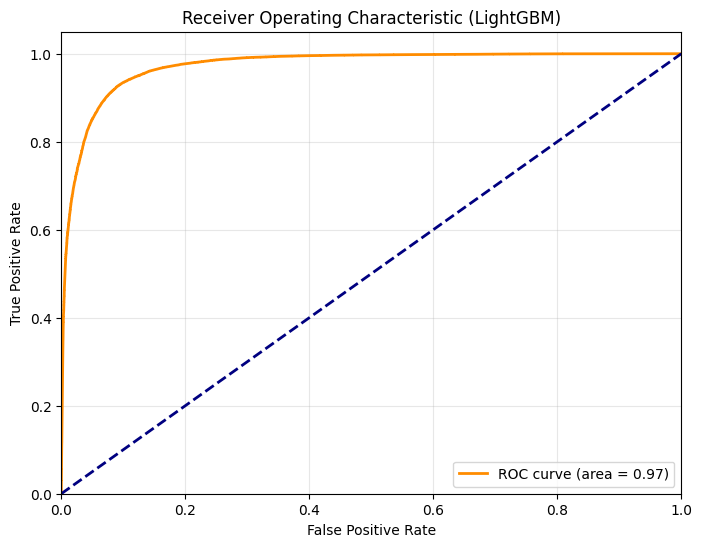

In [ ]:
from sklearn.model_selection import learning_curve
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# 1. Plot ROC Curve for LightGBM
plt.figure(figsize=(8, 6))
lgbm.fit(X_train, y_train)
y_score = lgbm.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_score)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (area = {roc_auc:0.2f})")
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (LightGBM)")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

[LOG] Computing learning curve (this may take a moment)... 


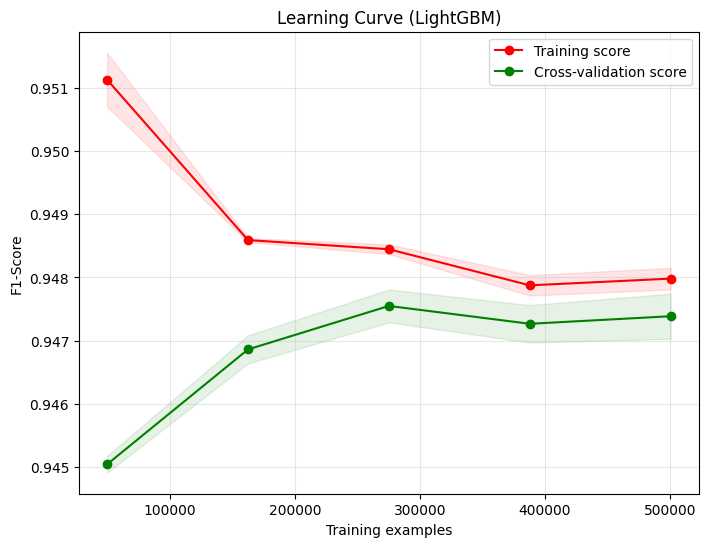

In [ ]:
# 2. Plot Learning Curve for LightGBM
print("[LOG] Computing learning curve ... ")
train_sizes, train_scores, test_scores = learning_curve(
    lgbm, X_train, y_train, cv=5, n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5), scoring="f1"
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_mean, "o-", color="r", label="Training score")
plt.plot(train_sizes, test_mean, "o-", color="g", label="Cross-validation score")
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color="r")
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color="g")
plt.xlabel("Training examples")
plt.ylabel("F1-Score")
plt.title("Learning Curve (LightGBM)")
plt.legend(loc="best")
plt.grid(alpha=0.3)
plt.show()

### UMAP Feature Extraction (6 Components)
We will now use UMAP to extract 6 components from the feature space. Note that UMAP is an unsupervised method here, so it only sees the features (X), not the labels (y).

In [ ]:
import umap
from sklearn.preprocessing import StandardScaler

# 1. Prepare the data for UMAP (dropping non-feature columns)
x_features = df_classic.drop(['label', 'url'], axis=1).fillna(0)

# 2. Scale the data (UMAP is sensitive to scale)
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x_features)

# 3. Fit UMAP on a sample to speed up computation
# Using 5000 for a quick extraction, increase n_neighbors or sample size for more detail
umap_model = umap.UMAP(n_components=6, n_neighbors=15, min_dist=0.1, random_state=42)

print("[LOG] Fitting UMAP on sample...")
sample_indices = np.random.choice(x_scaled.shape[0], size=min(5000, x_scaled.shape[0]), replace=False)
umap_model.fit(x_scaled[sample_indices])

# 4. Transform the entire dataset
print("[LOG] Transforming full dataset...")
umap_embeddings = umap_model.transform(x_scaled)

# 5. Add UMAP components to the dataframe
umap_cols = [f'umap_{i+1}' for i in range(6)]
df_umap = pd.DataFrame(umap_embeddings, columns=umap_cols, index=df_classic.index)
df_classic = pd.concat([df_classic, df_umap], axis=1)

print(f"Added 6 UMAP components: {umap_cols}")
display(df_classic[umap_cols].head())

In [ ]:
!pip install umap-learn openpyxl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.8/91.8 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.9/250.9 kB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.5/73.5 kB 7.6 MB/s eta 0:00:00


## deep model

In [ ]:
! pip install tensorflow
import tensorflow as tf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 777.5 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 118.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 104.0 MB/s eta 0:00:00
  Attempting uninstall: h5py
    Found existing installation: h5py 3.16.0
    Uninstalling h5py-3.16.0:
      Successfully uninstalled h5py-3.16.0


/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


In [ ]:
from tensorflow.keras import layers, Model

### transformerblock

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model

class TransformerBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, dropout=0.1):
        super().__init__()
        self.att = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = tf.keras.Sequential([
            layers.Dense(ff_dim, activation='gelu'),
            layers.Dense(embed_dim)
        ])
        self.norm1 = layers.LayerNormalization(epsilon=1e-6)
        self.norm2 = layers.LayerNormalization(epsilon=1e-6)
        self.drop1 = layers.Dropout(dropout)
        self.drop2 = layers.Dropout(dropout)

    def call(self, x, training=False):
        attn_output = self.att(x, x, training=training)
        attn_output = self.drop1(attn_output, training=training)
        out1 = self.norm1(x + attn_output)
        ffn_output = self.ffn(out1, training=training)
        ffn_output = self.drop2(ffn_output, training=training)
        return self.norm2(out1 + ffn_output)

In [ ]:
class AttentionPooling(layers.Layer):
  def __init__(self,hidden_dim):
    super().__init__()
    self.score_dense = layers.Dense(hidden_dim,activation='tanh')
    self.weight_dense = layers.Dense(1)
  def call(self,x):
    score = self.score_dense(x)
    weights = self.weight_dense(score)
    weights = tf.nn.softmax(weights,axis=1)
    pooled = tf.reduce_sum(weights*x,axis=1)
    return pooled

In [ ]:
class GatedFusion(layers.Layer):
  def __init__(self,out_dim):
    super().__init__()
    self.proj1 = layers.Dense(out_dim, activation='relu')
    self.proj2 = layers.Dense(out_dim, activation='relu')
    self.proj3 = layers.Dense(out_dim, activation='relu')
    self.gate = layers.Dense(3, activation='softmax')
  def call(self, inputs):
    x1, x2, x3 = inputs
    h1 = self.proj1(x1)
    h2 = self.proj2(x2)
    h3 = self.proj3(x3)

    concat = tf.concat([h1,h2,h3],axis=-1)
    gates = self.gate(concat)

    g1 = tf.expand_dims(gates[:, 0],axis=-1)
    g2 = tf.expand_dims(gates[:, 1],axis=-1)
    g3 = tf.expand_dims(gates[:, 2],axis=-1)

    return g1*x1 + g2*x2 + g3*x3

In [ ]:
def build_char_branch(vocab_size, seq_len, embed_dim=128):
  char_input = layers.Input(shape=(seq_len,),name="raw_url_input")
  x = layers.Embedding(vocab_size, embed_dim, mask_zero=True)(char_input)
  c1 = layers.Conv1D(128, kernel_size=3,padding='same',activation='relu')(x)
  c2 = layers.Conv1D(128, kernel_size=5,padding='same',activation='relu')(x)
  c3 = layers.Conv1D(128, kernel_size=7,padding='same',activation='relu')(x)
  x = layers.Concatenate()([c1,c2,c3])
  x = layers.Dense(embed_dim)(x)
  x = TransformerBlock(embed_dim=embed_dim, num_heads=4,ff_dim=256,dropout=0.1)(x)
  x = TransformerBlock(embed_dim=embed_dim, num_heads=4,ff_dim=256,dropout=0.1)(x)
  x = AttentionPooling(hidden_dim=64)(x)
  x = layers.Dense(128,activation='relu')(x)
  x = layers.Dropout(0.2)(x)
  return Model(char_input,x,name='char_branch')

In [ ]:
def build_segment_encoder(name, vocab_size, seq_len, embed_dim=64,rnn_units=64 ):
  seg_input = layers.Input(shape=(seq_len,),name=f"{name}_input")
  x = layers.Embedding(vocab_size, embed_dim)(seg_input)
  x = layers.Bidirectional(layers.LSTM(rnn_units,return_sequences=True))(x)
  x = AttentionPooling(hidden_dim=32)(x)
  x = layers.Dense(64,activation='relu')(x)
  return Model(seg_input,x,name=f"{name}_encoder")

In [ ]:
def build_structural_branch(vocab_size,segment_lenghts):
  sub_len, dom_len, path_len, query_len = segment_lenghts
  sub_encoder = build_segment_encoder('subdomain',vocab_size,sub_len)
  dom_encoder = build_segment_encoder('domain',vocab_size,dom_len)
  path_encoder = build_segment_encoder('path',vocab_size,path_len)
  query_encoder = build_segment_encoder('query',vocab_size,query_len)
  sub_in = sub_encoder.input
  dom_in = dom_encoder.input
  path_in = path_encoder.input
  query_in = query_encoder.input

  sub_vec = sub_encoder.output
  dom_vec = dom_encoder.output
  path_vec = path_encoder.output
  query_vec = query_encoder.output
  seg_stack = layers.Lambda(
        lambda t: tf.stack(t, axis=1),
        output_shape=(4, 64)
    )([sub_vec, dom_vec, path_vec, query_vec])
  x = TransformerBlock(embed_dim=64, num_heads=4, ff_dim=128, dropout=0.1)(seg_stack)
  x = AttentionPooling(hidden_dim=32)(x)
  x = layers.Dense(128, activation="relu")(x)
  x = layers.Dropout(0.2)(x)
  return Model([sub_in, dom_in, path_in, query_in], x, name="structural_branch")








In [ ]:
def build_feature_branch(num_features):
    feat_input = layers.Input(shape=(num_features,), name="feature_input")
    x = layers.Dense(64, activation="relu")(feat_input)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.2)(x)
    return Model(feat_input, x, name="feature_branch")

In [ ]:
def build_url_detector():
    char_branch = build_char_branch(...)
    structural_branch = build_structural_branch(...)
    feature_branch = build_feature_branch(...)
    raw_in = char_branch.input
    sub_in, dom_in, path_in, query_in = structural_branch.input
    feat_in = feature_branch.input
    char_vec = char_branch.output
    struct_vec = structural_branch.output
    feat_vec = feature_branch.output
    fused = GatedFusion(out_dim=128)([char_vec, struct_vec, feat_vec])
    x = layers.Dense(128, activation="relu")(fused)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.2)(x)

    output = layers.Dense(1, activation="sigmoid", name="malicious_output")(x)
    return output

In [ ]:
def binary_focal_loss(gamma=2,alpha=0.25):
  y_true = tf.cast(y_true, tf.float32)
  y_pred = tf.clip_by_value(y_pred, eps, 1.0 - eps)
  pt = tf.where(tf.equal(y_true, 1), y_pred, 1 - y_pred)
  alpha_t = tf.where(tf.equal(y_true, 1), alpha, 1 - alpha)
  alpha_t = tf.where(tf.equal(y_true, 1), alpha, 1 - alpha)
  focal = -alpha_t * tf.pow(1 - pt, gamma) * tf.math.log(pt)
  return tf.reduce_mean(focal)


### preprocess

In [ ]:
df_deep = pd.read_csv(r"/content/cleaned_phishing_dataset.csv")

In [ ]:
import pandas as pd
import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from urllib.parse import urlparse

# 0. Configuration
MAX_LEN_URL = 200
MAX_LEN_SUB = 20
MAX_LEN_DOM = 30
MAX_LEN_PATH = 100
MAX_LEN_QUERY = 50
VOCAB_SIZE = 100

# 1. Raw URL Preprocessing
tokenizer = Tokenizer(char_level=True, lower=True, oov_token='<OOV>')
tokenizer.fit_on_texts(df_deep['url'])
X_raw = pad_sequences(tokenizer.texts_to_sequences(df_deep['url']), maxlen=MAX_LEN_URL)

# 2. Structural Preprocessing
def parse_url_segments(url):
    try:
        safe_url = str(url).replace('[', '').replace(']', '')
        parsed = urlparse(safe_url)
        path = parsed.path
        query = parsed.query
        domain_parts = parsed.netloc.split('.')
        if len(domain_parts) > 2:
            subdomain = domain_parts[0]
            domain = domain_parts[1]
        else:
            subdomain = ''
            domain = domain_parts[0] if domain_parts else ''
    except:
        return '', '', '', ''
    return subdomain, domain, path, query

segments = df_deep['url'].apply(parse_url_segments)
sub_list, dom_list, path_list, query_list = zip(*segments)

X_sub = pad_sequences(tokenizer.texts_to_sequences(sub_list), maxlen=MAX_LEN_SUB)
X_dom = pad_sequences(tokenizer.texts_to_sequences(dom_list), maxlen=MAX_LEN_DOM)
X_path = pad_sequences(tokenizer.texts_to_sequences(path_list), maxlen=MAX_LEN_PATH)
X_query = pad_sequences(tokenizer.texts_to_sequences(query_list), maxlen=MAX_LEN_QUERY)

y = df_deep['label'].values

print(f"Preprocessing complete (No classical features).")
print(f"Shapes - Raw: {X_raw.shape}, Sub: {X_sub.shape}, Dom: {X_dom.shape}")

Preprocessing complete (No classical features).
Shapes - Raw: (781900, 200), Sub: (781900, 20), Dom: (781900, 30)


### Build and Compile Model
Now we initialize the architecture using the preprocessed dimensions and defined loss function.

In [ ]:
model = Model(
    inputs=[raw_in, sub_in, dom_in, path_in, query_in, feat_in],
    outputs=output,
    name="hierarchial_MultiView_URL_Detector"
)

NameError: name 'raw_in' is not defined

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model

# 1. Custom Layer Definitions
class AttentionPooling(layers.Layer):
    def __init__(self, hidden_dim):
        super().__init__()
        self.score_dense = layers.Dense(hidden_dim, activation='tanh')
        self.weight_dense = layers.Dense(1)

    def call(self, x):
        score = self.score_dense(x)
        weights = self.weight_dense(score)
        weights = tf.nn.softmax(weights, axis=1)
        pooled = tf.reduce_sum(weights * x, axis=1)
        return pooled

# 2. Helper Functions
def build_segment_encoder(name, vocab_size, seq_len, embed_dim=64, rnn_units=64):
    seg_input = layers.Input(shape=(seq_len,), name=f"{name}_input")
    x = layers.Embedding(vocab_size, embed_dim)(seg_input)
    x = layers.Bidirectional(layers.LSTM(rnn_units, return_sequences=True))(x)
    x = AttentionPooling(hidden_dim=32)(x)
    x = layers.Dense(64, activation='relu')(x)
    return Model(seg_input, x, name=f"{name}_encoder")

def build_char_branch(vocab_size, seq_len, embed_dim=128):
    char_input = layers.Input(shape=(seq_len,), name='raw_url_input')
    x = layers.Embedding(vocab_size, embed_dim, mask_zero=True)(char_input)
    # Drop mask for Conv1D compatibility
    x = layers.Lambda(lambda x: x)(x)
    c1 = layers.Conv1D(128, kernel_size=3, padding='same', activation='relu')(x)
    c2 = layers.Conv1D(128, kernel_size=5, padding='same', activation='relu')(x)
    c3 = layers.Conv1D(128, kernel_size=7, padding='same', activation='relu')(x)
    x = layers.Concatenate()([c1, c2, c3])
    x = layers.Dense(embed_dim)(x)
    x = TransformerBlock(embed_dim=embed_dim, num_heads=4, ff_dim=256, dropout=0.1)(x)
    x = TransformerBlock(embed_dim=embed_dim, num_heads=4, ff_dim=256, dropout=0.1)(x)
    x = AttentionPooling(hidden_dim=64)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    return Model(char_input, x, name='char_branch')

def build_structural_branch(vocab_size, segment_lengths):
    sub_len, dom_len, path_len, query_len = segment_lengths
    sub_encoder = build_segment_encoder('subdomain', vocab_size, sub_len)
    dom_encoder = build_segment_encoder('domain', vocab_size, dom_len)
    path_encoder = build_segment_encoder('path', vocab_size, path_len)
    query_encoder = build_segment_encoder('query', vocab_size, query_len)

    seg_stack = layers.Lambda(lambda t: tf.stack(t, axis=1))([sub_encoder.output, dom_encoder.output, path_encoder.output, query_encoder.output])
    x = TransformerBlock(embed_dim=64, num_heads=4, ff_dim=128, dropout=0.1)(seg_stack)
    x = AttentionPooling(hidden_dim=32)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    return Model(inputs=[sub_encoder.input, dom_encoder.input, path_encoder.input, query_encoder.input], outputs=x, name='structural_branch')

# 3. Model Assembly
def build_hierarchical_model():
    v_size = VOCAB_SIZE + 1
    s_lens = [MAX_LEN_SUB, MAX_LEN_DOM, MAX_LEN_PATH, MAX_LEN_QUERY]
    c_branch = build_char_branch(v_size, MAX_LEN_URL)
    s_branch = build_structural_branch(v_size, s_lens)
    fused = layers.Concatenate()([c_branch.output, s_branch.output])
    x = layers.Dense(128, activation='relu')(fused)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(64, activation='relu')(x)
    output = layers.Dense(1, activation='sigmoid', name='malicious_output')(x)
    model = Model(inputs=[c_branch.input] + s_branch.input, outputs=output, name='MultiView_URL_Detector')
    return model

# 4. Compile
final_model = build_hierarchical_model()
final_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
print("Model successfully assembled and compiled.")
final_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'lambda_2' (of type Lambda) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


Model successfully assembled and compiled.


Model: "MultiView_URL_Detector"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ raw_url_input       │ (None, 200)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_6         │ (None, 200, 128)  │     12,928 │ raw_url_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_2         │ (None, 200)       │          0 │ raw_url_input[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ subdomain_input     │ (None, 20)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ domain_input        │ (None, 30)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ path_input          │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ query_input         │ (None, 50)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_2 (Lambda)   │ (None, 200, 128)  │          0 │ embedding_6[0][0… │
│                     │                   │            │ not_equal_2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_7         │ (None, 20, 64)    │      6,464 │ subdomain_input[… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_8         │ (None, 30, 64)    │      6,464 │ domain_input[0][… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_9         │ (None, 100, 64)   │      6,464 │ path_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_10        │ (None, 50, 64)    │      6,464 │ query_input[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, 200, 128)  │     49,280 │ lambda_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_7 (Conv1D)   │ (None, 200, 128)  │     82,048 │ lambda_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_8 (Conv1D)   │ (None, 200, 128)  │    114,816 │ lambda_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_4     │ (None, 20, 128)   │     66,048 │ embedding_7[0][0] │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_5     │ (None, 30, 128)   │     66,048 │ embedding_8[0][0] │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_6     │ (None, 100, 128)  │     66,048 │ embedding_9[0][0

 Total params: 1,468,231 (5.60 MB)

 Trainable params: 1,468,231 (5.60 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 1. Initialize parameters
num_char_vocab = VOCAB_SIZE + 1
segment_lens = [MAX_LEN_SUB, MAX_LEN_DOM, MAX_LEN_PATH, MAX_LEN_QUERY]
num_features = X_feat.shape[1]

# 2. Build individual branches
char_branch = build_char_branch(num_char_vocab, MAX_LEN_URL)
struct_branch = build_structural_branch(num_char_vocab, segment_lens)
feat_branch = build_feature_branch(num_features)

# 3. Extract inputs and outputs for fusion
raw_in = char_branch.input
sub_in, dom_in, path_in, query_in = struct_branch.input
feat_in = feat_branch.input

char_vec = char_branch.output
struct_vec = struct_branch.output
feat_vec = feat_branch.output

# 4. Apply Gated Fusion and Classification Head
fused = GatedFusion(out_dim=128)([char_vec, struct_vec, feat_vec])
x = layers.Dense(128, activation="relu")(fused)
x = layers.Dropout(0.3)(x)
x = layers.Dense(64, activation="relu")(x)
x = layers.Dropout(0.2)(x)
output = layers.Dense(1, activation="sigmoid", name="malicious_output")(x)

# 5. Finalize Model
model = Model(
    inputs=[raw_in, sub_in, dom_in, path_in, query_in, feat_in],
    outputs=output,
    name="Hierarchical_MultiView_URL_Detector"
)

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)

print("Model assembled successfully.")
model.summary()

NameError: name 'X_feat' is not defined

In [ ]:
# 1. Initialize dimensions
num_char_vocab = VOCAB_SIZE + 1
segment_lens = [MAX_LEN_SUB, MAX_LEN_DOM, MAX_LEN_PATH, MAX_LEN_QUERY]
num_features = X_feat.shape[1]

# 2. Build sub-branches
char_branch = build_char_branch(num_char_vocab, MAX_LEN_URL)
struct_branch = build_structural_branch(num_char_vocab, segment_lens)
feat_branch = build_feature_branch(num_features)

# 3. Define Global Inputs
raw_in = char_branch.input
sub_in, dom_in, path_in, query_in = struct_branch.input
feat_in = feat_branch.input

# 4. Get branch outputs
char_vec = char_branch.output
struct_vec = struct_branch.output
feat_vec = feat_branch.output

# 5. Fusion and Classification Head
fused = GatedFusion(out_dim=128)([char_vec, struct_vec, feat_vec])
x = layers.Dense(128, activation="relu")(fused)
x = layers.Dropout(0.3)(x)
x = layers.Dense(64, activation="relu")(x)
x = layers.Dropout(0.2)(x)
output = layers.Dense(1, activation="sigmoid", name="malicious_output")(x)

# 6. Final Model
final_model = Model(
    inputs=[raw_in, sub_in, dom_in, path_in, query_in, feat_in],
    outputs=output,
    name="Hierarchical_MultiView_Phishing_Detector"
)

final_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name='auc'), tf.keras.metrics.Precision(name='precision'), tf.keras.metrics.Recall(name='recall')]
)

print("Model assembled and compiled successfully.")
final_model.summary()

NameError: name 'X_feat' is not defined

## after lots of troubles

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model


# ----------------------------
# Custom Layers
# ----------------------------

class TransformerBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, dropout=0.1):
        super().__init__()
        self.att = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = tf.keras.Sequential([
            layers.Dense(ff_dim, activation="gelu"),
            layers.Dense(embed_dim),
        ])
        self.norm1 = layers.LayerNormalization(epsilon=1e-6)
        self.norm2 = layers.LayerNormalization(epsilon=1e-6)
        self.drop1 = layers.Dropout(dropout)
        self.drop2 = layers.Dropout(dropout)

    def call(self, x, training=False):
        attn_output = self.att(x, x, training=training)
        attn_output = self.drop1(attn_output, training=training)
        out1 = self.norm1(x + attn_output)
        ffn_output = self.ffn(out1, training=training)
        ffn_output = self.drop2(ffn_output, training=training)
        return self.norm2(out1 + ffn_output)


class AttentionPooling(layers.Layer):
    def __init__(self, hidden_dim):
        super().__init__()
        self.score_dense = layers.Dense(hidden_dim, activation="tanh")
        self.weight_dense = layers.Dense(1)

    def call(self, x):
        score = self.score_dense(x)
        weights = tf.nn.softmax(self.weight_dense(score), axis=1)
        return tf.reduce_sum(weights * x, axis=1)


class GatedFusion(layers.Layer):
    def __init__(self, out_dim):
        super().__init__()
        self.proj1 = layers.Dense(out_dim, activation="relu")
        self.proj2 = layers.Dense(out_dim, activation="relu")
        self.proj3 = layers.Dense(out_dim, activation="relu")
        self.gate = layers.Dense(3, activation="softmax")

    def call(self, inputs):
        x1, x2, x3 = inputs
        h1, h2, h3 = self.proj1(x1), self.proj2(x2), self.proj3(x3)
        gates = self.gate(tf.concat([h1, h2, h3], axis=-1))
        g1 = tf.expand_dims(gates[:, 0], -1)
        g2 = tf.expand_dims(gates[:, 1], -1)
        g3 = tf.expand_dims(gates[:, 2], -1)
        return g1 * h1 + g2 * h2 + g3 * h3


# ----------------------------
# Branch Builders
# ----------------------------

def build_char_branch(vocab_size, seq_len, embed_dim=128):
    char_input = layers.Input(shape=(seq_len,), name="raw_url_input")
    x = layers.Embedding(vocab_size, embed_dim)(char_input)
    c1 = layers.Conv1D(128, 3, padding="same", activation="relu")(x)
    c2 = layers.Conv1D(128, 5, padding="same", activation="relu", dilation_rate=2)(x)
    c3 = layers.Conv1D(128, 7, padding="same", activation="relu", dilation_rate=3)(x)
    x = layers.Dense(embed_dim)(layers.Concatenate()([c1, c2, c3]))
    x = TransformerBlock(embed_dim, 4, 256, 0.1)(x)
    x = TransformerBlock(embed_dim, 4, 256, 0.1)(x)
    x = layers.Dropout(0.2)(layers.Dense(128, activation="relu")(AttentionPooling(64)(x)))
    return Model(char_input, x, name="char_branch")


def build_segment_encoder(name, vocab_size, seq_len, embed_dim=64, rnn_units=64):
    seg_input = layers.Input(shape=(seq_len,), name=f"{name}_input")
    x = layers.Embedding(vocab_size, embed_dim)(seg_input)
    x = layers.Bidirectional(layers.GRU(rnn_units, return_sequences=True))(x)
    x = layers.Dense(64, activation="relu")(AttentionPooling(32)(x))
    return Model(seg_input, x, name=f"{name}_encoder")


def build_structural_branch(vocab_size, segment_lengths):
    sub_len, dom_len, path_len, query_len = segment_lengths
    encoders = [
        build_segment_encoder("subdomain", vocab_size, sub_len),
        build_segment_encoder("domain", vocab_size, dom_len),
        build_segment_encoder("path", vocab_size, path_len),
        build_segment_encoder("query", vocab_size, query_len),
    ]
    inputs = [e.input for e in encoders]
    outputs = [e.output for e in encoders]
    seg_stack = layers.Lambda(lambda t: tf.stack(t, axis=1), output_shape=(4, 64))(outputs)
    x = TransformerBlock(64, 4, 128, 0.1)(seg_stack)
    x = layers.Dropout(0.2)(layers.Dense(128, activation="relu")(AttentionPooling(32)(x)))
    return Model(inputs, x, name="structural_branch")


def build_feature_branch(num_features):
    feat_input = layers.Input(shape=(num_features,), name="feature_input")
    x = layers.BatchNormalization()(feat_input)
    x = layers.Dropout(0.2)(layers.Dense(64, activation="relu")(x))
    x = layers.Dropout(0.2)(layers.Dense(64, activation="relu")(x))
    return Model(feat_input, x, name="feature_branch")


# ----------------------------
# Full Model
# ----------------------------

def build_url_detector(vocab_size, raw_url_len=200, sub_len=30, dom_len=30,
                        path_len=80, query_len=80, num_features=20):
    char_branch = build_char_branch(vocab_size, raw_url_len, 128)
    structural_branch = build_structural_branch(vocab_size, (sub_len, dom_len, path_len, query_len))
    feature_branch = build_feature_branch(num_features)

    fused = GatedFusion(128)([char_branch.output, structural_branch.output, feature_branch.output])
    x = layers.Dropout(0.3)(layers.Dense(128, activation="relu")(fused))
    x = layers.Dropout(0.2)(layers.Dense(64, activation="relu")(x))
    output = layers.Dense(1, activation="sigmoid", name="malicious_output")(x)

    return Model(
        inputs=[char_branch.input, *structural_branch.input, feature_branch.input],
        outputs=output,
        name="Hierarchical_MultiView_URL_Detector"
    )


# ----------------------------
# Focal Loss
# ----------------------------

def binary_focal_loss(gamma=2.0, alpha=0.25):
    def loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        eps = tf.keras.backend.epsilon()
        y_pred = tf.clip_by_value(y_pred, eps, 1.0 - eps)
        pt = tf.where(tf.equal(y_true, 1), y_pred, 1 - y_pred)
        alpha_t = tf.where(tf.equal(y_true, 1), alpha, 1 - alpha)
        return tf.reduce_mean(-alpha_t * tf.pow(1 - pt, gamma) * tf.math.log(pt))
    return loss


# ----------------------------
# Dataset Loading
# ----------------------------

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# Config
VOCAB_SIZE = 120
NUM_FEATURES = 20
RAW_URL_LEN = 200
SUB_LEN, DOM_LEN, PATH_LEN, QUERY_LEN = 30, 30, 80, 80

df = pd.read_csv("/content/cleaned_phishing_dataset.csv")

# --- Tokenization helpers ---
CHAR2IDX = {c: i+1 for i, c in enumerate(
    "abcdefghijklmnopqrstuvwxyz0123456789-._~:/?#[]@!$&'()*+,;=%"
)}

def tokenize(text, maxlen):
    text = str(text).lower()
    seq = [CHAR2IDX.get(c, 0) for c in text[:maxlen]]
    return seq + [0] * (maxlen - len(seq))

def parse_url_segments(url, sub_len=SUB_LEN, dom_len=DOM_LEN,
                        path_len=PATH_LEN, query_len=QUERY_LEN):
    from urllib.parse import urlparse
    try:
        p = urlparse(url if url.startswith("http") else "http://" + url)
        host = p.hostname or ""
        parts = host.split(".")
        subdomain = ".".join(parts[:-2]) if len(parts) > 2 else ""
        domain = ".".join(parts[-2:]) if len(parts) >= 2 else host
        path = p.path or ""
        query = p.query or ""
    except Exception:
        subdomain = domain = path = query = ""
    return (
        tokenize(subdomain, sub_len),
        tokenize(domain, dom_len),
        tokenize(path, path_len),
        tokenize(query, query_len),
    )

# Identify URL column and label column (adjust names as needed)
url_col = "url"          # change if your CSV uses a different column name
label_col = "label"      # change if your CSV uses a different column name

# Build raw URL tokens
raw_tokens = np.array([tokenize(u, RAW_URL_LEN) for u in df[url_col]], dtype=np.int32)

# Build segment tokens
segments = [parse_url_segments(u) for u in df[url_col]]
sub_tokens   = np.array([s[0] for s in segments], dtype=np.int32)
dom_tokens   = np.array([s[1] for s in segments], dtype=np.int32)
path_tokens  = np.array([s[2] for s in segments], dtype=np.int32)
query_tokens = np.array([s[3] for s in segments], dtype=np.int32)

# Handcrafted features: use numeric columns if present, else generate zeros
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if label_col in numeric_cols:
    numeric_cols.remove(label_col)
if len(numeric_cols) >= NUM_FEATURES:
    features = df[numeric_cols[:NUM_FEATURES]].fillna(0).values.astype(np.float32)
else:
    # Pad with zeros if not enough numeric columns
    base = df[numeric_cols].fillna(0).values.astype(np.float32) if numeric_cols else np.zeros((len(df), 0), dtype=np.float32)
    pad = np.zeros((len(df), NUM_FEATURES - base.shape[1]), dtype=np.float32)
    features = np.concatenate([base, pad], axis=1)

labels = df[label_col].values.astype(np.float32)

# Train/val split
idx = np.arange(len(df))
tr, va = train_test_split(idx, test_size=0.2, random_state=42, stratify=labels)

X_train = [raw_tokens[tr], sub_tokens[tr], dom_tokens[tr], path_tokens[tr], query_tokens[tr], features[tr]]
X_val   = [raw_tokens[va], sub_tokens[va], dom_tokens[va], path_tokens[va], query_tokens[va], features[va]]
y_train, y_val = labels[tr], labels[va]

# ----------------------------
# Build + Compile + Train
# ----------------------------

model = build_url_detector(
    vocab_size=VOCAB_SIZE,
    raw_url_len=RAW_URL_LEN,
    sub_len=SUB_LEN,
    dom_len=DOM_LEN,
    path_len=PATH_LEN,
    query_len=QUERY_LEN,
    num_features=NUM_FEATURES
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=binary_focal_loss(gamma=2.0, alpha=0.25),
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="acc"),
        tf.keras.metrics.AUC(name="auc"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
    ]
)

model.summary()

checkpoint_callback = ModelCheckpoint(
    filepath='best_model.weights.h5',
    save_weights_only=True,
    monitor='val_auc',
    mode='max',
    save_best_only=True,
    verbose=1
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=64,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(patience=2, factor=0.5),
        checkpoint_callback
    ]
)


Model: "Hierarchical_MultiView_URL_Detector"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ raw_url_input       │ (None, 200)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ subdomain_input     │ (None, 30)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ domain_input        │ (None, 30)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ path_input          │ (None, 80)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ query_input         │ (None, 80)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_5         │ (None, 200, 128)  │     15,360 │ raw_url_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_6         │ (None, 30, 64)    │      7,680 │ subdomain_input[… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_7         │ (None, 30, 64)    │      7,680 │ domain_input[0][… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_8         │ (None, 80, 64)    │      7,680 │ path_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_9         │ (None, 80, 64)    │      7,680 │ query_input[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 200, 128)  │     49,280 │ embedding_5[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 200, 128)  │     82,048 │ embedding_5[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 200, 128)  │    114,816 │ embedding_5[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_4     │ (None, 30, 128)   │     49,920 │ embedding_6[0][0] │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_5     │ (None, 30, 128)   │     49,920 │ embedding_7[0][0] │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_6     │ (None, 80, 128)   │     49,920 │ embedding_8[0][0] │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_7     │ (None, 80, 128)   │     49,920 │ embedding_9[0][0] │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 200, 384)  │          0 │ conv1d_3[0][0], 

 Total params: 1,442,714 (5.50 MB)

 Trainable params: 1,442,674 (5.50 MB)

 Non-trainable params: 40 (160.00 B)

Epoch 1/10
 178/9774 ━━━━━━━━━━━━━━━━━━━━ 7:33:47 3s/step - acc: 0.3437 - auc: 0.5027 - loss: 0.0700 - precision: 0.6949 - recall: 0.0684

### Clarifying Data Splits for Ensemble

It's crucial for ensembling that both models make predictions on the *same set of data instances* for the validation/test phase. While the internal feature representations are different (LightGBM uses tabular `good_features` from `df_classic`, and the deep model uses tokenized URL parts and extracted numerical features from `df_deep`), the original rows corresponding to the validation set must be identical.

In the deep model's training cell (`Na09AoMSg96b`), a `train_test_split` was performed using `tr` and `va` indices on the `df` (which is `df_deep`). We will use these exact `tr` and `va` indices to prepare the corresponding training and validation data for the LightGBM model from `df_classic` to ensure consistency.

Furthermore, the `lgbm` pipeline object in the global scope needs to be explicitly trained on this consistent training split, as its previous training happened within a function (`run_all_models_final`) and did not update the global `lgbm` variable.

In [ ]:
# Prepare LightGBM data using the same train/validation split indices (tr, va) as the deep model

# Ensure 'good_features' is accessible. It was defined in cell 'oi6cQQenvFdJ'
# If 'good_features' is not defined, uncomment and define it here or ensure the cell 'oi6cQQenvFdJ' is run.
# good_features = ['num_subdomains', 'num_dots', 'entropy', 'url_length', 'domain_length', 'num_digits', 'path_length', 'query_length', 'contains_login', 'num_hyphens', 'num_slashes', 'contains_wp'] # Example, ensure this matches actual 'good_features'

# The original df_classic is loaded in 'nOcqiRwIp0iB'
# Ensure df_classic is loaded and good_features is defined before this cell runs.

# Filter df_classic to include only good_features and the label
X_lgbm_all = df_classic[good_features]
y_lgbm_all = df_classic['label']

# Use the 'tr' and 'va' indices from the deep model's split (defined in Na09AoMSg96b)
X_train_lgbm_ensemble = X_lgbm_all.iloc[tr]
y_train_lgbm_ensemble = y_lgbm_all.iloc[tr]

X_val_lgbm_ensemble = X_lgbm_all.iloc[va]
y_val_lgbm_ensemble = y_lgbm_all.iloc[va]

print(f"[LOG] LightGBM ensemble training data shape: {X_train_lgbm_ensemble.shape}")
print(f"[LOG] LightGBM ensemble validation data shape: {X_val_lgbm_ensemble.shape}")

# Explicitly train the global lgbm model pipeline
print("[LOG] Training LightGBM model for ensemble...")

lgbm.fit(X_train_lgbm_ensemble, y_train_lgbm_ensemble)

print("[LOG] LightGBM model trained for ensemble.")


## Ensemble Implementation (LightGBM + Deep Model)

With both models trained and using a consistent validation split, we can now combine their predictions and evaluate the ensemble.

In [ ]:
print('[LOG] Performing ensemble...')

# 1. Get predictions from the deep model on the validation set (X_val and y_val are from Na09AoMSg96b)
deep_model_predictions = model.predict(X_val).flatten()

# 2. Get predictions from the *explicitly trained* LightGBM model on its consistent validation set
lgbm_predictions = lgbm.predict_proba(X_val_lgbm_ensemble)[:, 1]

# The labels for evaluation are y_val (from the deep model split), which should be identical to y_val_lgbm_ensemble
# We'll use y_val for consistency with the deep model's evaluation.

# 3. Combine predictions (simple weighted average example)
# You can adjust these weights based on model performance or validation results
weight_lgbm = 0.5
weight_deep = 0.5

ensemble_predictions = (weight_lgbm * lgbm_predictions) + (weight_deep * deep_model_predictions)

# Convert probabilities to binary predictions
ensemble_binary_predictions = (ensemble_predictions > 0.5).astype(int)

# 4. Evaluate the ensemble
enh_accuracy = accuracy_score(y_val, ensemble_binary_predictions)
enh_precision = precision_score(y_val, ensemble_binary_predictions, zero_division=0)
enh_recall = recall_score(y_val, ensemble_binary_predictions, zero_division=0)
enh_f1 = f1_score(y_val, ensemble_binary_predictions, zero_division=0)
enh_roc_auc = roc_auc_score(y_val, ensemble_predictions)

print(f"\nEnsemble Model Performance:")
print(f"Accuracy: {enh_accuracy:.4f}")
print(f"Precision: {enh_precision:.4f}")
print(f"Recall: {enh_recall:.4f}")
print(f"F1-Score: {enh_f1:.4f}")
print(f"ROC AUC: {enh_roc_auc:.4f}")

# You can also generate a classification report for more detailed metrics
print("\nClassification Report for Ensemble Model:")
print(classification_report(y_val, ensemble_binary_predictions, zero_division=0))
